--- 1. GENERAL DATASET OVERVIEW ---
1. Manufacturing Years: 2003 to 2018
2. Lowest Selling Price: 0.1 Lakhs
3. Highest Selling Price: 35.0 Lakhs
4. Total Records: 301
5. Missing Records per Column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

6. Unique Vehicle Names: 98
7. Most Sold Vehicle: city
8. CNG Vehicles Present: Yes (Total: 2)
9. Individual Seller Vehicles: 106
10. Automatic Transmission Vehicles: Yes (Total: 40)
11. Single Person Owned (1st Hand): 290



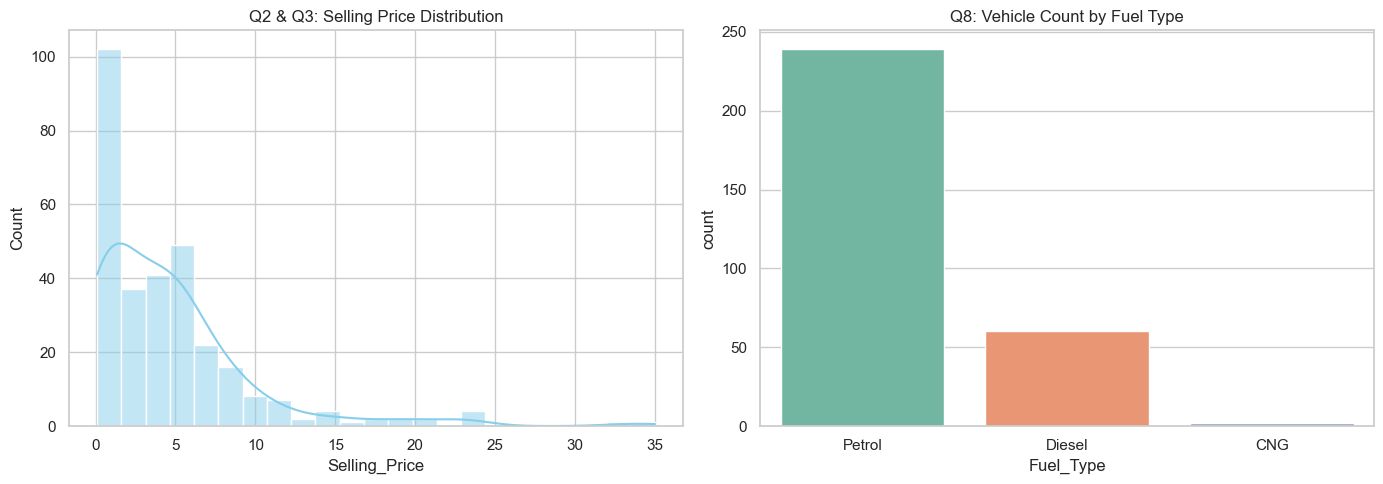

--- 2. COST DEPRECIATION ANALYSIS ---
12. Most Depreciated: land cruiser | Least Depreciated: Honda Activa 4G
13. Top 5 Brands Least Affected by Depreciation:
Brand
um          0.120000
activa      0.183333
tvs         0.242750
mahindra    0.250000
yamaha      0.258750
Name: Cost_Depreciation, dtype: float64



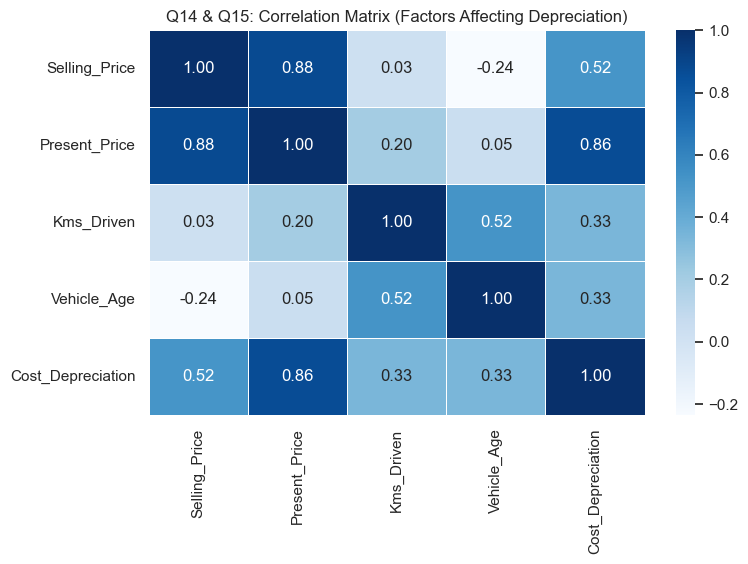

16. Vehicles Manufactured After 2014: 147 records

--- 3. TWO-WHEELERS (BIKES) ANALYSIS ---
17. Two-Wheelers Count: 86
18. Oldest Bike: Hero Super Splendor (2005)
19. Newest Bike: KTM RC200 (2017)
20. Most Sold Bike: Royal Enfield Classic 350
21. Exceeded Expectation Bike Deal: Royal Enfield Thunder 500 sold for 1.75 Lakhs.
    Reason: Premium brand segment (e.g. Royal Enfield/KTM), high displacement, or low usage.



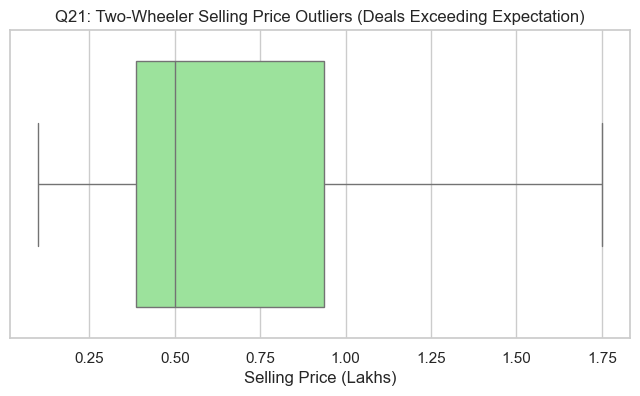

--- 4. CARS ANALYSIS ---
22. Cars Count: 215
23. Oldest Car: 800 (2003)
24. Newest Car: vitara brezza (2018)
25. Exceeded Expectation Car Deal: land cruiser sold for 35.0 Lakhs.
    Reason: Luxury vehicle segment, automatic transmission, or original high showroom price.


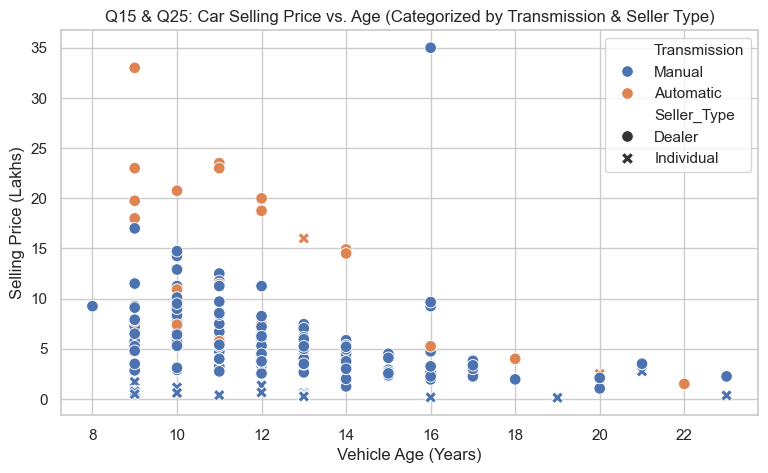

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('car_data.csv') # Adjust path if in data/ folder: '../data/car_data.csv'

# --- 1. GENERAL DATASET ANALYSIS (Q1 - Q11) ---
print("--- 1. GENERAL DATASET OVERVIEW ---")
print(f"1. Manufacturing Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"2. Lowest Selling Price: {df['Selling_Price'].min()} Lakhs")
print(f"3. Highest Selling Price: {df['Selling_Price'].max()} Lakhs")
print(f"4. Total Records: {len(df)}")
print(f"5. Missing Records per Column:\n{df.isnull().sum()}\n")
print(f"6. Unique Vehicle Names: {df['Car_Name'].nunique()}")
print(f"7. Most Sold Vehicle: {df['Car_Name'].value_counts().idxmax()}")

# Q8 - Q11 Counts
cng_count = len(df[df['Fuel_Type'].str.strip() == 'CNG'])
ind_count = len(df[df['Seller_Type'].str.strip() == 'Individual'])
auto_count = len(df[df['Transmission'].str.strip() == 'Automatic'])
owner_count = len(df[df['Owner'] == 0])

print(f"8. CNG Vehicles Present: {'Yes' if cng_count > 0 else 'No'} (Total: {cng_count})")
print(f"9. Individual Seller Vehicles: {ind_count}")
print(f"10. Automatic Transmission Vehicles: {'Yes' if auto_count > 0 else 'No'} (Total: {auto_count})")
print(f"11. Single Person Owned (1st Hand): {owner_count}\n")

# VISUALIZATION 1: Distribution of Selling Price & Fuel Types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Q2 & Q3: Selling Price Distribution')

sns.countplot(data=df, x='Fuel_Type', ax=axes[1], hue='Fuel_Type', palette='Set2', legend=False)
axes[1].set_title('Q8: Vehicle Count by Fuel Type')
plt.tight_layout()
plt.show()

# --- 2. DEPRECIATION ANALYSIS (Q12 - Q16) ---
print("--- 2. COST DEPRECIATION ANALYSIS ---")
current_year = 2026
df['Vehicle_Age'] = current_year - df['Year']
df['Cost_Depreciation'] = df['Present_Price'] - df['Selling_Price']

most_dep = df.loc[df['Cost_Depreciation'].idxmax()]['Car_Name']
least_dep = df.loc[df['Cost_Depreciation'].idxmin()]['Car_Name']
print(f"12. Most Depreciated: {most_dep} | Least Depreciated: {least_dep}")

df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0].lower())
brand_dep = df.groupby('Brand')['Cost_Depreciation'].mean().sort_values()
print(f"13. Top 5 Brands Least Affected by Depreciation:\n{brand_dep.head(5)}\n")

# VISUALIZATION 2: Factors Affecting Depreciation (Q14 & Q15 Correlation Heatmap)
plt.figure(figsize=(8, 5))
corr_matrix = df[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Vehicle_Age', 'Cost_Depreciation']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Q14 & Q15: Correlation Matrix (Factors Affecting Depreciation)')
plt.show()

# Q16: Vehicles after 2014
after_2014 = df[df['Year'] > 2014]
print(f"16. Vehicles Manufactured After 2014: {len(after_2014)} records\n")

# --- 3. TWO-WHEELERS (BIKES) ANALYSIS (Q17 - Q21) ---
print("--- 3. TWO-WHEELERS (BIKES) ANALYSIS ---")
bike_keywords = ['royal', 'bullet', 'ktm', 'duke', 'bajaj', 'pulsar', 'avenger', 
                 'hero', 'splendor', 'passion', 'activa', 'tvs', 'apache', 'yamaha', 'suzuki', 'karizma', 'gixxer']
pattern = '|'.join(bike_keywords)

bikes_df = df[df['Car_Name'].str.lower().str.contains(pattern, na=False)]
print(f"17. Two-Wheelers Count: {len(bikes_df)}")

if len(bikes_df) > 0:
    oldest_bike = bikes_df.loc[bikes_df['Year'].idxmin()]
    newest_bike = bikes_df.loc[bikes_df['Year'].idxmax()]
    most_sold_bike = bikes_df['Car_Name'].value_counts().idxmax()
    top_bike_deal = bikes_df.sort_values(by='Selling_Price', ascending=False).iloc[0]
    
    print(f"18. Oldest Bike: {oldest_bike['Car_Name']} ({oldest_bike['Year']})")
    print(f"19. Newest Bike: {newest_bike['Car_Name']} ({newest_bike['Year']})")
    print(f"20. Most Sold Bike: {most_sold_bike}")
    print(f"21. Exceeded Expectation Bike Deal: {top_bike_deal['Car_Name']} sold for {top_bike_deal['Selling_Price']} Lakhs.")
    print("    Reason: Premium brand segment (e.g. Royal Enfield/KTM), high displacement, or low usage.\n")

# VISUALIZATION 3: Bike Price Outliers & Deals (Q21)
if len(bikes_df) > 0:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=bikes_df, x='Selling_Price', color='lightgreen')
    plt.title('Q21: Two-Wheeler Selling Price Outliers (Deals Exceeding Expectation)')
    plt.xlabel('Selling Price (Lakhs)')
    plt.show()

# --- 4. CARS ANALYSIS (Q22 - Q25) ---
print("--- 4. CARS ANALYSIS ---")
cars_df = df[~df['Car_Name'].str.lower().str.contains(pattern, na=False)]
print(f"22. Cars Count: {len(cars_df)}")

oldest_car = cars_df.loc[cars_df['Year'].idxmin()]
newest_car = cars_df.loc[cars_df['Year'].idxmax()]
top_car_deal = cars_df.sort_values(by='Selling_Price', ascending=False).iloc[0]

print(f"23. Oldest Car: {oldest_car['Car_Name']} ({oldest_car['Year']})")
print(f"24. Newest Car: {newest_car['Car_Name']} ({newest_car['Year']})")
print(f"25. Exceeded Expectation Car Deal: {top_car_deal['Car_Name']} sold for {top_car_deal['Selling_Price']} Lakhs.")
print("    Reason: Luxury vehicle segment, automatic transmission, or original high showroom price.")

# VISUALIZATION 4: Car Price vs. Vehicle Age Scatter Plot (Q15 & Q25)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=cars_df, x='Vehicle_Age', y='Selling_Price', hue='Transmission', style='Seller_Type', s=70)
plt.title('Q15 & Q25: Car Selling Price vs. Age (Categorized by Transmission & Seller Type)')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()